In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [82]:
# https://github.com/abhishekvsmanni/Garden_City_Task/blob/main/ua_raw.20200618.csv

In [84]:
mrk_data = pd.read_csv('https://raw.githubusercontent.com/abhishekvsmanni/Garden_City_Task/main/ua_raw.20200618.csv')

In [85]:
mrk_data

,date,id,daily_budget,spend,impressions,clicks,installs,gross_revenue_iap_cohort,net_revenue_iap_cohort,purchases_cohort,...,purchasers_d24,purchasers_d25,purchasers_d26,purchasers_d27,purchasers_d28,purchasers_d56,purchasers_d84,purchasers_d112,purchasers_d280,purchasers_d364
0,2020-05-02,89704676509703517,11822,127.25,19160,153,94,129.69,90.8638,31,...,7.0,7.0,7.0,7.0,7.0,0.0,0.0,0.0,0.0,0.0
1,2019-10-31,89705461021313517,2424,22.72,3113,5,7,21.97,15.1492,3,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0.0
2,2019-11-02,89708853318503517,17500,168.08,14479,247,176,478.36,335.1390,64,...,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,1.0
3,2019-10-07,89704469509703517,1577,15.91,2615,36,26,0.99,0.5775,1,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
4,2020-05-03,89704469509703517,6987,66.32,17408,148,70,33.91,19.8052,15,...,4.0,4.0,4.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2865,2020-03-20,89704676509703517,7500,72.04,13266,143,116,589.30,412.8636,70,...,10.0,10.0,10.0,10.0,10.0,10.0,9.0,0.0,0.0,0.0
2866,2020-05-15,89708853318503517,10000,103.58,12221,140,79,329.67,230.9668,33,...,7.0,7.0,7.0,7.0,7.0,0.0,0.0,0.0,0.0,0.0
2867,2020-01-04,89701377223703517,12251,111.75,41878,649,321,298.56,187.7385,44,...,17.0,17.0,17.0,17.0,17.0,17.0,17.0,17.0,0.0,0.0
2868,2019-10-27,89708853318503517,27500,276.56,21366,350,244,2581.97,1808.9282,203,...,38.0,39.0,39.0,39.0,39.0,40.0,40.0,40.0,40.0,0.0


**EDA- Explorative Data Analysis**

In [86]:
display(mrk_data.columns)

Index(['date', 'id', 'daily_budget', 'spend', 'impressions', 'clicks',
       'installs', 'gross_revenue_iap_cohort', 'net_revenue_iap_cohort',
       'purchases_cohort',
       ...
       'purchasers_d24', 'purchasers_d25', 'purchasers_d26', 'purchasers_d27',
       'purchasers_d28', 'purchasers_d56', 'purchasers_d84', 'purchasers_d112',
       'purchasers_d280', 'purchasers_d364'],
      dtype='object', length=117)

In [87]:
mrk_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2870 entries, 0 to 2869
Columns: 117 entries, date to purchasers_d364
dtypes: float64(109), int64(7), object(1)
memory usage: 2.6+ MB


In [88]:
missing_values = mrk_data.isnull().sum()
missing_values_df = pd.DataFrame({'Column Name': missing_values.index, 'Null Count': missing_values.values})
display(missing_values_df)

,Column Name,Null Count
0,date,0
1,id,0
2,daily_budget,0
3,spend,0
4,impressions,0
...,...,...
112,purchasers_d56,0
113,purchasers_d84,0
114,purchasers_d112,0
115,purchasers_d280,0


In [89]:
mrk_data[['spend', 'installs', 'net_revenue_d3', 'net_revenue_d56']].describe()

,spend,installs,net_revenue_d3,net_revenue_d56
count,2870.000000,2870.000000,2870.000000,2870.000000
mean,67.845774,148.380488,65.752517,113.357906
std,42.623108,172.475981,72.634887,173.613967
min,0.210000,0.000000,0.000000,0.000000
25%,28.747500,38.250000,13.920075,7.224950
50%,70.565000,84.000000,45.592950,61.587250
75%,98.637500,184.000000,90.619100,153.778050
max,333.500000,1247.000000,588.483600,2558.510000


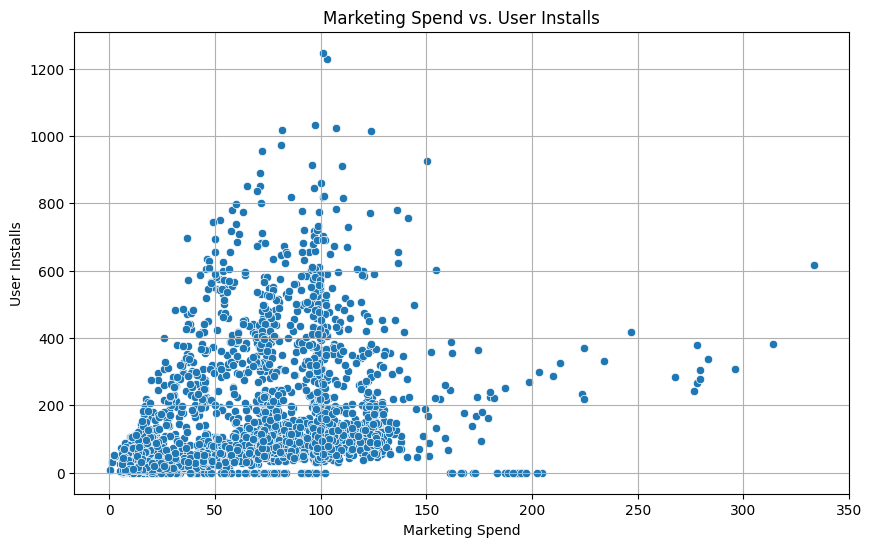

In [90]:
# Visualizing Spend vs. Acquisition

plt.figure(figsize=(10, 6))
sns.scatterplot(data=mrk_data, x='spend', y='installs')
plt.title('Marketing Spend vs. User Installs')
plt.xlabel('Marketing Spend')
plt.ylabel('User Installs')
plt.grid(True)
plt.show()

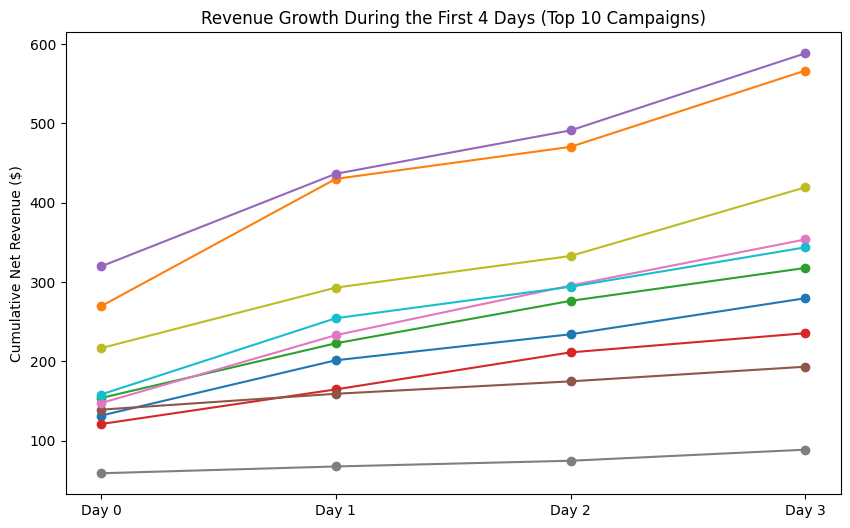

In [91]:
# Analyzing Revenue Maturity (D0 to D3)

# Select a few campaigns to see their growth trajectory
revenue_cols = ['net_revenue_d0', 'net_revenue_d1', 'net_revenue_d2', 'net_revenue_d3']
sample_data = mrk_data.nlargest(10, 'spend')[revenue_cols].T

plt.figure(figsize=(10, 6))
plt.plot(sample_data, marker='o')
plt.title('Revenue Growth During the First 4 Days (Top 10 Campaigns)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Day 0', 'Day 1', 'Day 2', 'Day 3'])
plt.ylabel('Cumulative Net Revenue ($)')
plt.show()

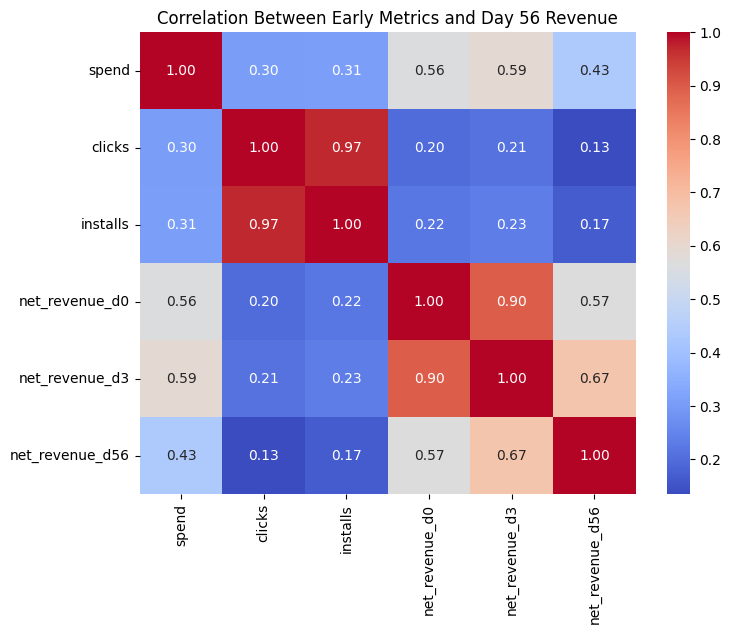

In [92]:
# Correlation Heatmap

# Select relevant early metrics and the target
corr_cols = ['spend', 'clicks', 'installs', 'net_revenue_d0', 'net_revenue_d3', 'net_revenue_d56']
correlation_matrix = mrk_data[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Early Metrics and Day 56 Revenue')
plt.show()

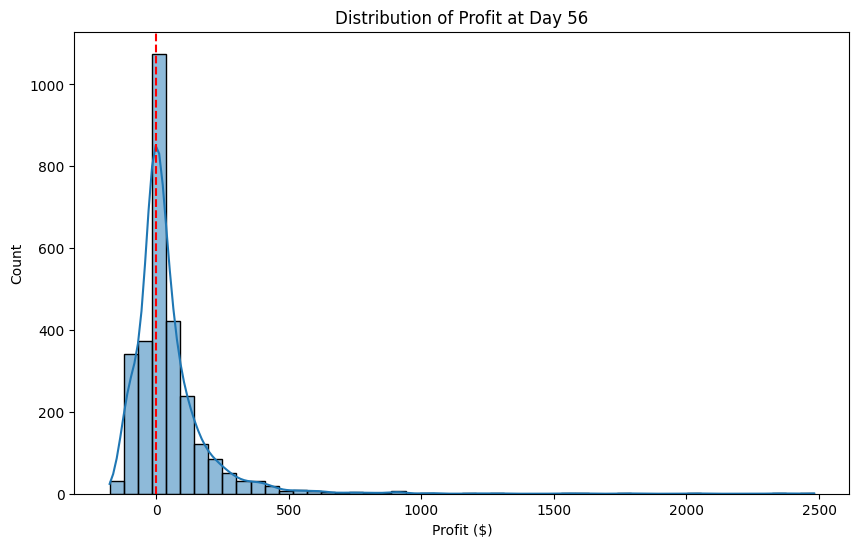

In [93]:
# Defining the Target Variable

# profit_d56 = net_revenue_d56 - spend
mrk_data['profit_d56'] = mrk_data['net_revenue_d56'] - mrk_data['spend']

# Visualize the distribution of profit
plt.figure(figsize=(10, 6))
sns.histplot(mrk_data['profit_d56'], bins=50, kde=True)
plt.title('Distribution of Profit at Day 56')
plt.axvline(0, color='red', linestyle='--') # Line at zero profit
plt.xlabel('Profit ($)')
plt.show()

In [94]:
# Preparing the Model (The "4-Day Constraint")

# Select only the features we know by Day 3
# We include Spend, Installs, and Revenue metrics from the start to Day 3
features = [
    'spend', 'installs', 'clicks',
    'net_revenue_d0', 'net_revenue_d1', 'net_revenue_d2', 'net_revenue_d3'
]

X = mrk_data[features]       # Our inputs
y = mrk_data['profit_d56']   # Our target

# Split the data so we can "test" the model on data it hasn't seen before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into Training and Testing sets.")

Data split into Training and Testing sets.


In [95]:
# Training and Evaluation

# 1. Initialize the model
model = LinearRegression()

# 2. Train the model using the training data
model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred = model.predict(X_test)

# 4. Calculate MAD (Mean Absolute Error)
mad = mean_absolute_error(y_test, y_pred)

print(f"--- MODEL RESULTS ---")
print(f"Mean Absolute Deviation (MAD): ${mad:.2f}")
print(f"This means on average, our profit prediction is off by ${mad:.2f}")

--- MODEL RESULTS ---
Mean Absolute Deviation (MAD): $55.62
This means on average, our profit prediction is off by $55.62


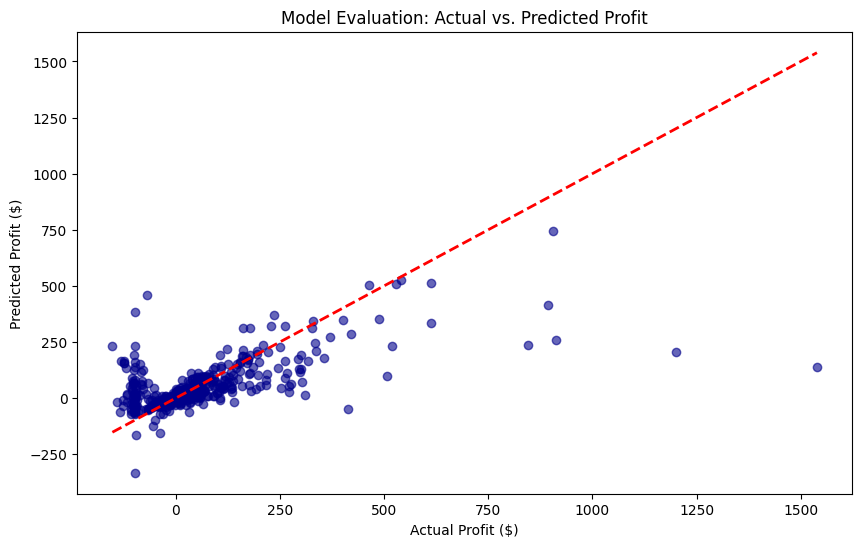

In [96]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='darkblue')

# Draw a red line showing where "Perfect Predictions" would be
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.xlabel('Actual Profit ($)')
plt.ylabel('Predicted Profit ($)')
plt.title('Model Evaluation: Actual vs. Predicted Profit')
plt.show()

In [97]:
# Display R-squared and MAD
print(f"R-squared: {r_squared:.2f}")
print(f"Mean Absolute Deviation (MAD): ${mad:.2f}")

R-squared: 0.41
Mean Absolute Deviation (MAD): $55.62


In [98]:
# Model Evaluation Metrics

from sklearn.metrics import r2_score, mean_squared_error
import math

# Calculate R-squared
r_squared = r2_score(y_test, y_pred)
print(f"R-squared: {r_squared:.2f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Calculate Root Mean Squared Error (RMSE)
rmse = math.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Calculate Mean Absolute Error (MAD) - already available as 'mad'
print(f"Mean Absolute Deviation (MAD): ${mad:.2f}")

R-squared: 0.41
Mean Squared Error (MSE): 14302.61
Root Mean Squared Error (RMSE): 119.59
Mean Absolute Deviation (MAD): $55.62


### Residual Analysis

Residual plots help us check the assumptions of linear regression and identify potential issues with the model, such as non-linearity or heteroscedasticity.

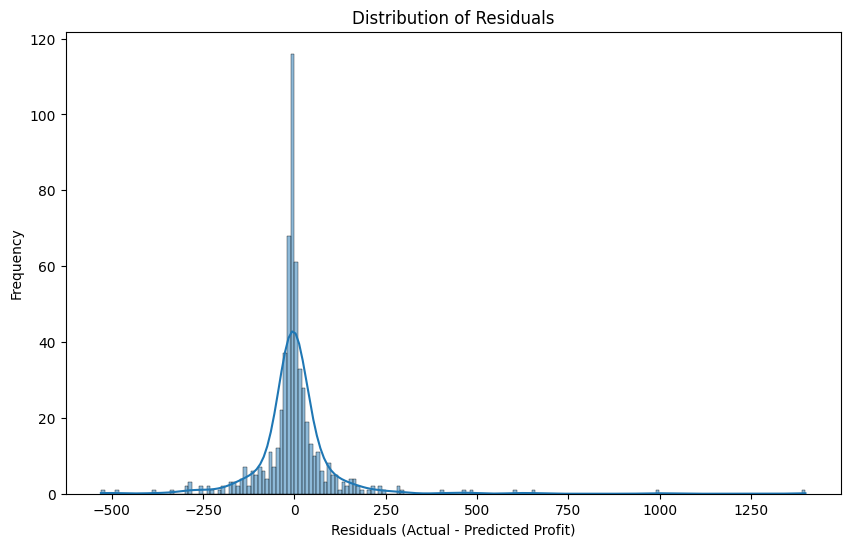

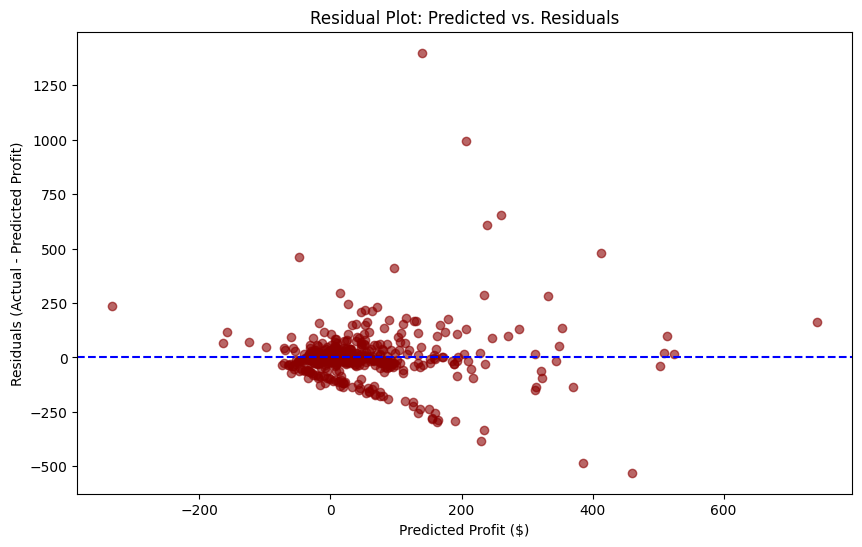

In [99]:
# Calculate Residuals
residuals = y_test - y_pred

# Plot 1: Distribution of Residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals (Actual - Predicted Profit)')
plt.ylabel('Frequency')
plt.show()

# Plot 2: Residual Plot (Predicted vs. Residuals)
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='darkred')
plt.axhline(y=0, color='blue', linestyle='--')
plt.xlabel('Predicted Profit ($)')
plt.ylabel('Residuals (Actual - Predicted Profit)')
plt.title('Residual Plot: Predicted vs. Residuals')
plt.show()

Early Identification of Winners: Imagine a campaign manager launches five new campaigns. After just three days, they can input the initial spend, installs, clicks, and net_revenue_d0 to d3 from each campaign into our model. If Campaign A is predicted to yield a profit_d56 of $500, while Campaign B is predicted at -$20 , the manager can immediately increase the budget for Campaign A to scale its success and pause or reallocate funds from Campaign B, preventing further losses.

Resource Optimization: Instead of waiting 56 days to know if a campaign was profitable, managers get an early warning system. This means they can avoid wasting significant budget on underperforming campaigns by cutting them short, and aggressively push successful ones, leading to more efficient use of marketing spend and a better overall return on investment.

Data-Driven Decisions: When reporting to stakeholders or planning future campaigns, managers can use the model's predictions to justify strategic decisions. For instance, they can say, 'Based on early performance indicators, we project Campaign X will generate a $300 profit per cohort by Day 56, supporting our decision to double its budget.'
